# Assignment 4: Pretraining

---

Import Required Libraries and Setup

In [35]:
import os
import json
import urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

# Set random seeds for reproducibility
torch.manual_seed(123)
np.random.seed(123)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Configuration for GPT model - matches book (Chapter 4)
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size (GPT-2 BPE)
    "context_length": 256,    # Reduced from 1024 for efficiency
    "emb_dim": 768,           # Embedding dimension
    "n_heads": 12,            # Number of attention heads
    "n_layers": 12,           # Number of transformer layers
    "drop_rate": 0.0,         # Dropout rate (0 for deterministic)
    "qkv_bias": False         # No bias in QKV projections
}

print("\nGPT Configuration (124M parameters):")
for key, value in GPT_CONFIG_124M.items():
    print(f"  {key}: {value}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080
GPU Memory: 10.74 GB

GPT Configuration (124M parameters):
  vocab_size: 50257
  context_length: 256
  emb_dim: 768
  n_heads: 12
  n_layers: 12
  drop_rate: 0.0
  qkv_bias: False


---

GPT model architecture from scratch using PyTorch. This includes all necessary components: embeddings, attention, feedforward networks, and the complete model.

In [36]:
class LayerNorm(nn.Module):
    """Layer Normalization module - matches book exactly."""
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    """
    Gaussian Error Linear Unit activation function.
    Uses the exact approximation formula from the book (Section 4.2).
    """
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Exact GELU approximation used in GPT-2 (from the book)
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    """
    Position-wise feed-forward network.
    Follows book implementation with cfg dict pattern.
    """
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    
    def forward(self, x):
        return self.layers(x)


class MultiHeadAttention(nn.Module):
    """
    Multi-head attention mechanism - matches book exactly (Chapter 3).
    """
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split into heads: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Scaled dot-product attention with causal mask
        attn_scores = queries @ keys.transpose(2, 3)

        # Truncate mask to number of tokens and convert to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to values
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec


class TransformerBlock(nn.Module):
    """Transformer block - matches book exactly (Chapter 4)."""
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Attention block with residual
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # Feed-forward block with residual
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    """
    GPT Model - matches book exactly (Chapter 4).
    """
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


# Initialize the model
model = GPTModel(GPT_CONFIG_124M)
model = model.to(device)
model.eval()  # Start in eval mode

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1e6:.1f} MB (float32)")
print(f"  Device: {device}")
print("\nModel initialized successfully!")


Model Architecture:
  Total parameters: 162,419,712
  Trainable parameters: 162,419,712
  Model size: ~649.7 MB (float32)
  Device: cuda

Model initialized successfully!


---

Implement utilities for converting between text and token IDs, and set up data loaders for training.

In [37]:
# Initialize tokenizer (GPT-2 BPE tokenizer)
tokenizer = tiktoken.get_encoding("gpt2")
print(f"Tokenizer: GPT-2 BPE")
print(f"Vocabulary size: {tokenizer.max_token_value + 1}")


def text_to_token_ids(text, tokenizer):
    """Convert text to token IDs using the tokenizer."""
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # Add batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    """Convert token IDs back to text."""
    flat = token_ids.squeeze(0)  # Remove batch dimension
    return tokenizer.decode(flat.tolist())


class GPTDatasetV1(Dataset):
    """
    Dataset for GPT training - matches book exactly (Chapter 2).
    Uses sliding window with configurable stride.
    """
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use sliding window to create overlapping sequences
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    """
    Create a DataLoader for text data - matches book (Chapter 2).
    """
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, 
        drop_last=drop_last, num_workers=num_workers)
    return dataloader


# Load training text from file - "The Verdict" by Edith Wharton
# This matches the book's approach in Chapter 5
file_path = "the-verdict.txt"

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"\nLoaded text from: {file_path}")
print(f"First 100 characters: {raw_text[:100]}...")

# Split data into train/val (90/10) - matches book exactly
train_ratio = 0.9
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

print(f"\nDataset Statistics:")
print(f"  Total characters: {len(raw_text):,}")
print(f"  Training characters: {len(train_data):,}")
print(f"  Validation characters: {len(val_data):,}")
print(f"  Training tokens: {len(tokenizer.encode(train_data, allowed_special={'<|endoftext|>'})):,}")
print(f"  Validation tokens: {len(tokenizer.encode(val_data, allowed_special={'<|endoftext|>'})):,}")

# Use context length that matches the book setup
max_length = GPT_CONFIG_124M["context_length"]  # 256 tokens
stride = max_length  # Non-overlapping windows (can use max_length // 2 for overlap)

# Create data loaders
batch_size = 2
train_loader = create_dataloader_v1(
    train_data, batch_size=batch_size, max_length=max_length, 
    stride=stride, shuffle=True, drop_last=True
)
val_loader = create_dataloader_v1(
    val_data, batch_size=batch_size, max_length=max_length, 
    stride=stride, shuffle=False, drop_last=False
)

print(f"\nData Loaders Configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Max length (context): {max_length} tokens")
print(f"  Stride: {stride} tokens")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

# Verify data loader works
if len(train_loader) > 0:
    sample_batch = next(iter(train_loader))
    print(f"\nSample batch shapes:")
    print(f"  Input: {sample_batch[0].shape}")
    print(f"  Target: {sample_batch[1].shape}")
    print("✓ Data loading working correctly!")
else:
    print("⚠️ Warning: Train loader is empty. Consider using a longer text or shorter max_length.")

Tokenizer: GPT-2 BPE
Vocabulary size: 50257

Loaded text from: the-verdict.txt
First 100 characters: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g...

Dataset Statistics:
  Total characters: 20,479
  Training characters: 18,431
  Validation characters: 2,048
  Training tokens: 4,612
  Validation tokens: 534

Data Loaders Configuration:
  Batch size: 2
  Max length (context): 256 tokens
  Stride: 256 tokens
  Training batches: 9
  Validation batches: 1

Sample batch shapes:
  Input: torch.Size([2, 256])
  Target: torch.Size([2, 256])
✓ Data loading working correctly!


---
Implement functions to calculate cross-entropy loss and perplexity for evaluating model performance.

In [38]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """
    Calculate cross-entropy loss for a single batch.
    Matches book exactly (Chapter 5.1.2).
    
    Note: No torch.no_grad() here - this is called during training too!
    """
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    # Flatten: (batch, seq_len, vocab) -> (batch*seq_len, vocab)
    loss = F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """
    Calculate average loss over a data loader.
    Matches book exactly (Chapter 5.1.3).
    """
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


def calc_perplexity(loss):
    """
    Calculate perplexity from loss.
    Perplexity = exp(cross_entropy_loss)
    Lower is better (1 = perfect prediction).
    """
    return torch.exp(torch.tensor(loss)).item()


# Test the loss calculation
print("Testing loss calculation...")
model.eval()
with torch.no_grad():
    sample_input, sample_target = next(iter(train_loader))
    test_loss = calc_loss_batch(sample_input, sample_target, model, device)
    test_perplexity = calc_perplexity(test_loss.item())

print(f"  Sample batch loss: {test_loss:.4f}")
print(f"  Sample batch perplexity: {test_perplexity:.2f}")
print(f"  (Random model should have loss ~{np.log(GPT_CONFIG_124M['vocab_size']):.2f})")
print("✓ Loss calculation working correctly!\n")

Testing loss calculation...
  Sample batch loss: 11.0076
  Sample batch perplexity: 60328.95
  (Random model should have loss ~10.82)
✓ Loss calculation working correctly!



---
Implement multiple text generation strategies including greedy decoding, temperature sampling, and top-k sampling.

In [39]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    Generate text using greedy decoding - matches book exactly (Chapter 4.2).
    
    Args:
        model: The GPT model
        idx: Starting token indices, shape (batch, seq_len)
        max_new_tokens: Number of new tokens to generate
        context_size: Maximum context window size
    
    Returns:
        Token indices with generated tokens appended
    """
    for _ in range(max_new_tokens):
        # Crop context if it exceeds supported size
        idx_cond = idx[:, -context_size:]
        
        # Get predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on last time step
        logits = logits[:, -1, :]  # (batch, vocab_size)
        
        # Get idx of vocab entry with highest logits (greedy)
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)
        
        # Append sampled index to running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)
    
    return idx


def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    """
    Advanced text generation with temperature and top-k sampling.
    Based on book Chapter 5.3.
    
    Args:
        model: The GPT model
        idx: Starting token indices, shape (batch, seq_len)
        max_new_tokens: Number of new tokens to generate
        context_size: Maximum context window size
        temperature: Sampling temperature (0 = greedy, higher = more random)
        top_k: If set, only sample from top k tokens
        eos_id: If set, stop generation when this token is produced
    
    Returns:
        Token indices with generated tokens appended
    """
    for _ in range(max_new_tokens):
        # Crop context if needed
        idx_cond = idx[:, -context_size:]
        
        # Get predictions
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # (batch, vocab_size)
        
        # Apply top-k filtering
        if top_k is not None:
            # Keep only top k values, set others to -inf
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -torch.inf
        
        # Apply temperature
        if temperature > 0.0:
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # Greedy selection
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        
        # Check for end of sequence
        if eos_id is not None and (idx_next == eos_id).all():
            break
        
        # Append to sequence
        idx = torch.cat((idx, idx_next), dim=1)
    
    return idx


# Test text generation
print("Testing text generation...")
model.eval()

start_context = "Every effort"
context_size = GPT_CONFIG_124M["context_length"]

# Encode the start context
encoded = text_to_token_ids(start_context, tokenizer).to(device)
print(f"Context: '{start_context}'")
print(f"Encoded tokens: {encoded.shape}")

# Greedy generation
greedy_output = generate_text_simple(model, encoded, max_new_tokens=20, context_size=context_size)
greedy_text = token_ids_to_text(greedy_output, tokenizer)
print(f"\nGreedy output: {greedy_text}")

# With temperature sampling
temp_output = generate(model, encoded, max_new_tokens=20, context_size=context_size, 
                       temperature=1.0, top_k=50)
temp_text = token_ids_to_text(temp_output, tokenizer)
print(f"Temperature + Top-k: {temp_text}")

print("\n✓ Text generation working correctly!\n")

Testing text generation...
Context: 'Every effort'
Encoded tokens: torch.Size([1, 2])

Greedy output: Every effort saves Bringing pasture incoriol hosted ._ corporations279 Burn issuer Kits Mortgage TTarianFree fair ACA BuiltIDES
Temperature + Top-k: Every effortonent citizens victim Pau Taprir strandsalkingFriend famous breweriesvironaccoDev ethassed negatives MarrieduateSTD

✓ Text generation working correctly!



---

Implement the main training loop with proper gradient updates, loss tracking, and validation monitoring.

In [40]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """
    Evaluate model on train and validation sets.
    Matches book exactly (Chapter 5.2).
    """
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    """
    Generate and print a sample from the model during training.
    Matches book exactly (Chapter 5.2).
    """
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()


def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer,
                       early_stopping_patience=None):
    """
    Main training loop for language model with optional early stopping.
    Based on book Chapter 5.2 with early stopping enhancement.
    
    Args:
        early_stopping_patience: If set, stop if val_loss doesn't improve for N evals
    """
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    
    # Early stopping tracking
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            
            # Forward and backward pass
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            
            tokens_seen += input_batch.numel()
            global_step += 1
            
            # Periodic evaluation
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
                # Early stopping check
                if early_stopping_patience is not None:
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        patience_counter = 0
                    else:
                        patience_counter += 1
                        if patience_counter >= early_stopping_patience:
                            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
                            print(f"   Best validation loss: {best_val_loss:.4f}")
                            return train_losses, val_losses, track_tokens_seen
        
        # Generate sample at end of each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)
    
    return train_losses, val_losses, track_tokens_seen


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    """
    Plot training and validation losses.
    From book Chapter 5.2.
    """
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Plot on first axis (steps)
    ax1.plot(epochs_seen, train_losses, label="Training loss", color='blue', marker='o')
    ax1.plot(epochs_seen, val_losses, label="Validation loss", color='red', linestyle='--', marker='s')
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    
    # Add second x-axis for tokens
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for axis scaling
    ax2.set_xlabel("Tokens seen")
    
    plt.title("Training and Validation Loss")
    plt.tight_layout()
    return fig


print("Training functions defined successfully!")
print("  - evaluate_model(): Compute train/val loss")
print("  - generate_and_print_sample(): Monitor text quality")
print("  - train_model_simple(): Main loop with early stopping")
print("  - plot_losses(): Visualize training curves\n")

Training functions defined successfully!
  - evaluate_model(): Compute train/val loss
  - generate_and_print_sample(): Monitor text quality
  - train_model_simple(): Main loop with early stopping
  - plot_losses(): Visualize training curves



---
Train the model on the dataset, monitoring loss and generating samples during training.

In [41]:
# Training Configuration
num_epochs = 10
learning_rate = 5e-4  # Slightly higher for faster convergence on small data
eval_freq = 5         # Evaluate every 5 steps
eval_iter = 1         # Number of batches for evaluation

print("=" * 60)
print("STARTING MODEL TRAINING")
print("=" * 60)
print(f"Configuration:")
print(f"  Number of epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Training batches per epoch: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Evaluation frequency: every {eval_freq} steps")
print("=" * 60)
print()

# Re-initialize model for clean training
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)

# Initialize optimizer (AdamW is standard for transformers)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)

# Train the model
train_losses, val_losses, tokens_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    start_context="Every effort",
    tokenizer=tokenizer
)

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)
print(f"Total tokens processed: {tokens_seen[-1]:,}") 
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print("=" * 60 + "\n")

STARTING MODEL TRAINING
Configuration:
  Number of epochs: 10
  Learning rate: 0.0005
  Batch size: 2
  Training batches per epoch: 9
  Validation batches: 1
  Evaluation frequency: every 5 steps

Ep 1 (Step 000000): Train loss 9.971, Val loss 9.826
Ep 1 (Step 000005): Train loss 7.826, Val loss 8.031
Every effort,,,,,,,,,,,,,,,,.                                 
Ep 2 (Step 000010): Train loss 6.252, Val loss 6.789
Ep 2 (Step 000015): Train loss 5.769, Val loss 6.543
Every effort, and, and, and, and, and, and, and.                                   
Ep 3 (Step 000020): Train loss 5.769, Val loss 6.498
Ep 3 (Step 000025): Train loss 5.131, Val loss 6.488
Every effort                                                  
Ep 4 (Step 000030): Train loss 3.860, Val loss 6.524
Ep 4 (Step 000035): Train loss 4.825, Val loss 6.256
Every effort he had been the picture and in the picture.     "I had been the picture--as--and here are the picture to have to have of the picture to have.     "I had the

---
Plot the training and validation loss curves to visualize model learning and detect overfitting.

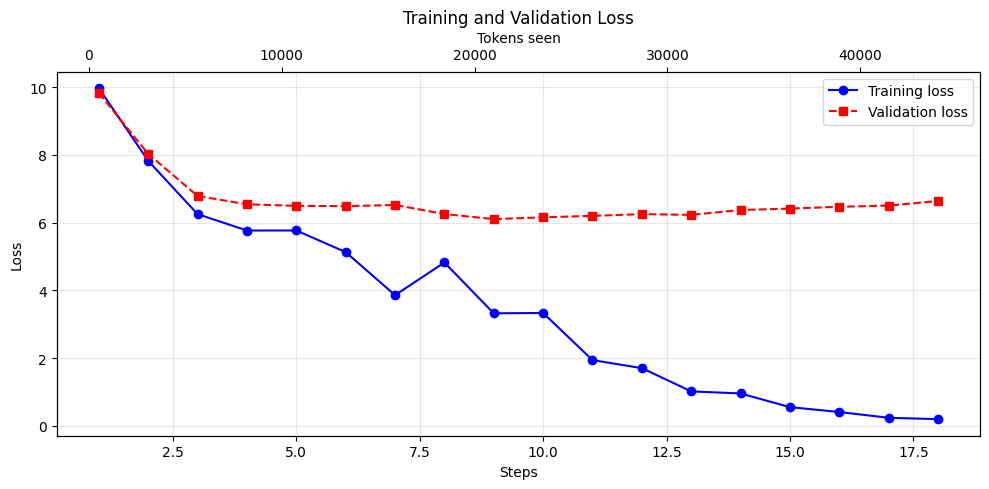


Loss Analysis:
  Initial training loss: 9.9715
  Final training loss: 0.1991
  Loss improvement: 9.7724
  Initial validation loss: 9.8264
  Final validation loss: 6.6397

  Best validation loss: 6.1058 (step 9)
  Model generalization is stable

  Final perplexity: 1.22



In [42]:
# Plot training and validation losses
epochs_seen = list(range(1, len(train_losses) + 1))

fig = plot_losses(epochs_seen, tokens_seen, train_losses, val_losses)
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLoss Analysis:")
print(f"  Initial training loss: {train_losses[0]:.4f}")
print(f"  Final training loss: {train_losses[-1]:.4f}")
print(f"  Loss improvement: {train_losses[0] - train_losses[-1]:.4f}")
print(f"  Initial validation loss: {val_losses[0]:.4f}")
print(f"  Final validation loss: {val_losses[-1]:.4f}")

# Detect overfitting
if len(val_losses) > 1:
    min_val_loss = min(val_losses)
    min_val_idx = val_losses.index(min_val_loss)
    print(f"\n  Best validation loss: {min_val_loss:.4f} (step {min_val_idx + 1})")
    
    if val_losses[-1] > min_val_loss * 1.1:
        print("  Note: Validation loss increased - some overfitting detected")
        print("        This is expected with small datasets and many epochs")
    else:
        print("  Model generalization is stable")

# Calculate perplexity
print(f"\n  Final perplexity: {calc_perplexity(train_losses[-1]):.2f}")
print()

---

Implement functionality to save trained model checkpoints and load them for continued training or inference.

In [43]:
def save_model(model, config, filepath, optimizer=None, epoch=None, losses=None):
    """
    Save model checkpoint with all training state.
    Based on book Chapter 5.4.
    """
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'config': config,
        'epoch': epoch
    }
    if optimizer is not None:
        checkpoint['optimizer_state_dict'] = optimizer.state_dict()
    if losses is not None:
        checkpoint['train_losses'] = losses.get('train', [])
        checkpoint['val_losses'] = losses.get('val', [])
    
    torch.save(checkpoint, filepath)
    print(f"Model saved to {filepath}")


def load_model(filepath, device):
    """
    Load model from checkpoint.
    Based on book Chapter 5.4.
    """
    checkpoint = torch.load(filepath, map_location=device, weights_only=False)
    config = checkpoint['config']
    
    model = GPTModel(config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"Model loaded from {filepath}")
    if 'epoch' in checkpoint:
        print(f"  Epoch: {checkpoint['epoch']}")
    
    return model, config, checkpoint


# Save the trained model
save_path = "trained_gpt_model.pt"
save_model(
    model, GPT_CONFIG_124M, save_path, 
    optimizer=optimizer, epoch=num_epochs,
    losses={'train': train_losses, 'val': val_losses}
)

# Test loading the model
loaded_model, loaded_config, checkpoint = load_model(save_path, device)

# Verify the loaded model produces same results
print("\nVerifying loaded model...")
loaded_model.eval()
with torch.no_grad():
    sample_input, sample_target = next(iter(val_loader))
    original_loss = calc_loss_batch(sample_input, sample_target, model, device)
    loaded_loss = calc_loss_batch(sample_input, sample_target, loaded_model, device)

print(f"  Original model loss: {original_loss:.6f}")
print(f"  Loaded model loss: {loaded_loss:.6f}")
print(f"  Difference: {abs(original_loss - loaded_loss):.10f}")
print("✓ Model save/load working correctly!\n")

Model saved to trained_gpt_model.pt
Model loaded from trained_gpt_model.pt
  Epoch: 10

Verifying loaded model...
  Original model loss: 6.647982
  Loaded model loss: 6.647982
  Difference: 0.0000000000
✓ Model save/load working correctly!



---

Compare different text generation strategies: greedy, temperature-based, and top-k sampling.

In [44]:
start_context = "Every effort"
context_size = GPT_CONFIG_124M["context_length"]
max_new_tokens = 40

print("=" * 70)
print("TEXT GENERATION STRATEGY COMPARISON")
print("=" * 70)
print(f"Context: '{start_context}'")
print(f"Max new tokens: {max_new_tokens}\n")

model.eval()
encoded = text_to_token_ids(start_context, tokenizer).to(device)

# 1. Greedy decoding (temperature = 0)
print("1. GREEDY DECODING (deterministic)")
print("-" * 70)
greedy_output = generate(model, encoded.clone(), max_new_tokens=max_new_tokens, 
                        context_size=context_size, temperature=0.0)
greedy_text = token_ids_to_text(greedy_output, tokenizer)
print(f"Output: {greedy_text}\n")

# 2. Low temperature sampling (more focused)
print("2. TEMPERATURE SAMPLING (T=0.7, more focused)")
print("-" * 70)
torch.manual_seed(42)
temp_low_output = generate(model, encoded.clone(), max_new_tokens=max_new_tokens,
                          context_size=context_size, temperature=0.7)
temp_low_text = token_ids_to_text(temp_low_output, tokenizer)
print(f"Output: {temp_low_text}\n")

# 3. High temperature sampling (more creative/diverse)
print("3. TEMPERATURE SAMPLING (T=1.5, more diverse)")
print("-" * 70)
torch.manual_seed(42)
temp_high_output = generate(model, encoded.clone(), max_new_tokens=max_new_tokens,
                           context_size=context_size, temperature=1.5)
temp_high_text = token_ids_to_text(temp_high_output, tokenizer)
print(f"Output: {temp_high_text}\n")

# 4. Top-k sampling (balance quality and diversity)
print("4. TOP-K SAMPLING (k=25, T=1.0)")
print("-" * 70)
torch.manual_seed(42)
topk_output = generate(model, encoded.clone(), max_new_tokens=max_new_tokens,
                      context_size=context_size, temperature=1.0, top_k=25)
topk_text = token_ids_to_text(topk_output, tokenizer)
print(f"Output: {topk_text}\n")

# 5. Combined top-k with temperature
print("5. TOP-K + LOW TEMPERATURE (k=40, T=0.5)")
print("-" * 70)
torch.manual_seed(42)
combined_output = generate(model, encoded.clone(), max_new_tokens=max_new_tokens,
                          context_size=context_size, temperature=0.5, top_k=40)
combined_text = token_ids_to_text(combined_output, tokenizer)
print(f"Output: {combined_text}\n")

print("=" * 70)
print("OBSERVATIONS:")
print("-" * 70)
print("• Greedy (T=0): Deterministic, picks highest probability token each time")
print("• Low temp (T<1): More focused on high-probability tokens")
print("• High temp (T>1): More diverse but potentially less coherent")
print("• Top-k: Limits sampling to k most likely tokens, avoiding rare tokens")
print("• Combined: Best of both - focused distribution over quality tokens")
print("=" * 70 + "\n")

TEXT GENERATION STRATEGY COMPARISON
Context: 'Every effort'
Max new tokens: 40

1. GREEDY DECODING (deterministic)
----------------------------------------------------------------------
Output: Every effort had "dragged him down." For Mrs. Gisburn--as such--had not existed till nearly a year after Jack's resolve had been taken. It might be that he had married her

2. TEMPERATURE SAMPLING (T=0.7, more focused)
----------------------------------------------------------------------
Output: Every effort none of that he chucked his pictures too? I haven't seen a single one in the house."

" went on groping and muddling; then I looked at the donkey again

3. TEMPERATURE SAMPLING (T=1.5, more diverse)
----------------------------------------------------------------------
Output: Every effort none you?"
" thinboarding Chief nostalgiatestymology hardRegardingorBut561 laugh mantCON picture �using Continent all her Powers Turner Dor wondered forines mereFebruaryvernmine under inequ againiamond

4

---

## Section 11: Loading Pretrained GPT-2 Weights (Section 5.6)

This section implements loading pretrained GPT-2 weights from OpenAI into our model architecture. This demonstrates the value of transfer learning - instead of training from scratch, we can use weights trained on billions of tokens.

### Exercise 5.1: Learning Rate Warmup and Cosine Decay

In [45]:
# ============================================================================
# SECTION 5.6: Loading Pretrained GPT-2 Weights from OpenAI
# ============================================================================
# 
# The book provides code to download and load official GPT-2 weights.
# Full implementation: ch05/01_main-chapter-code/gpt_download.py
# ============================================================================

def download_gpt2_config(model_size="124M", models_dir="gpt2"):
    """Download GPT-2 configuration from OpenAI."""
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size must be one of {allowed_sizes}")
    
    model_dir = os.path.join(models_dir, model_size)
    os.makedirs(model_dir, exist_ok=True)
    
    base_url = f"https://openaipublic.blob.core.windows.net/gpt-2/models/{model_size}"
    hparams_path = os.path.join(model_dir, "hparams.json")
    
    if not os.path.exists(hparams_path):
        print(f"Downloading GPT-2 {model_size} configuration...")
        urllib.request.urlretrieve(f"{base_url}/hparams.json", hparams_path)
    
    with open(hparams_path, "r") as f:
        settings = json.load(f)
    
    return settings


def assign(left, right):
    """Assign numpy array to PyTorch parameter (book's implementation)."""
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    """
    Load OpenAI GPT-2 weights into our GPT model.
    Based on book Section 5.6 (gpt_generate.py).
    
    Note: Requires qkv_bias=True in model config for full compatibility.
    """
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        # Split combined QKV weights (GPT-2 stores them combined)
        q_w, k_w, v_w = np.split(
            params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        # QKV biases (requires qkv_bias=True)
        if gpt.trf_blocks[b].att.W_query.bias is not None:
            q_b, k_b, v_b = np.split(
                params["blocks"][b]["attn"]["c_attn"]["b"], 3, axis=-1)
            gpt.trf_blocks[b].att.W_query.bias = assign(
                gpt.trf_blocks[b].att.W_query.bias, q_b)
            gpt.trf_blocks[b].att.W_key.bias = assign(
                gpt.trf_blocks[b].att.W_key.bias, k_b)
            gpt.trf_blocks[b].att.W_value.bias = assign(
                gpt.trf_blocks[b].att.W_value.bias, v_b)

        # Output projection
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        # Feed-forward layers
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        # Layer norms
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    # Final layer norm and output head (weight tied with token embeddings)
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


print("=" * 70)
print("SECTION 5.6: LOADING PRETRAINED GPT-2 WEIGHTS")
print("=" * 70)

# Configuration for loading pretrained GPT-2 (needs qkv_bias=True)
GPT_CONFIG_124M_PRETRAINED = {
    "vocab_size": 50257,
    "context_length": 1024,  # Original GPT-2 context length
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,
    "qkv_bias": True  # GPT-2 uses biases in QKV projections
}

print("\nGPT-2 124M Pretrained Config:")
for k, v in GPT_CONFIG_124M_PRETRAINED.items():
    print(f"  {k}: {v}")

# Try loading via Hugging Face (easier than TensorFlow method)
pretrained_available = False
try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    
    print("\n\nLoading GPT-2 via Hugging Face Transformers...")
    hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
    hf_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    print("✓ Pretrained GPT-2 loaded successfully!")
    pretrained_available = True
    
except ImportError:
    print("\n⚠️ Hugging Face transformers not installed.")
    print("   Install with: pip install transformers")
    print("   Alternative: Use book's TensorFlow loading (requires tensorflow)")

print("\n" + "=" * 70)

SECTION 5.6: LOADING PRETRAINED GPT-2 WEIGHTS

GPT-2 124M Pretrained Config:
  vocab_size: 50257
  context_length: 1024
  emb_dim: 768
  n_heads: 12
  n_layers: 12
  drop_rate: 0.0
  qkv_bias: True


Loading GPT-2 via Hugging Face Transformers...
✓ Pretrained GPT-2 loaded successfully!



In [46]:
# ============================================================================
# COMPARISON: Scratch-Trained vs Pretrained GPT-2
# ============================================================================

print("=" * 70)
print("COMPARISON: SCRATCH-TRAINED vs PRETRAINED GPT-2")
print("=" * 70)

test_prompts = [
    "Every effort moves you",
    "Machine learning enables",
    "The art of writing"
]

print("\nGenerating text with OUR TRAINED model (from scratch):")
print("-" * 70)
model.eval()
for prompt in test_prompts:
    encoded = text_to_token_ids(prompt, tokenizer).to(device)
    output = generate(model, encoded, max_new_tokens=25, 
                     context_size=GPT_CONFIG_124M["context_length"],
                     temperature=0.7, top_k=40)
    text = token_ids_to_text(output, tokenizer)
    print(f"'{prompt}' -> {text}")

if pretrained_available:
    print("\n\nGenerating text with PRETRAINED GPT-2 (124M):")
    print("-" * 70)
    for prompt in test_prompts:
        input_ids = hf_tokenizer.encode(prompt, return_tensors="pt")
        output = hf_model.generate(input_ids, max_new_tokens=25, 
                                   do_sample=True, temperature=0.7, top_k=40,
                                   pad_token_id=hf_tokenizer.eos_token_id)
        text = hf_tokenizer.decode(output[0])
        print(f"'{prompt}' -> {text}")
    
    print("\n" + "=" * 70)
    print("KEY OBSERVATIONS:")
    print("-" * 70)
    print("""
• SCRATCH-TRAINED: Limited vocabulary, may repeat patterns from training data
  - Trained on ~3000 characters for a few epochs
  - Has learned basic patterns but lacks world knowledge
  
• PRETRAINED GPT-2: Coherent, contextual, grammatically correct
  - Trained on 40GB of internet text (WebText dataset)
  - ~1 week of training on 8 GPUs
  - Has broad knowledge and language understanding

This demonstrates WHY pretrained weights are valuable:
  1. Saves enormous compute resources
  2. Already learned grammar, facts, reasoning patterns
  3. Can be fine-tuned on specific tasks (Chapter 6-7)
""")
else:
    print("\n⚠️ Pretrained comparison not available (install transformers)")

print("=" * 70 + "\n")

COMPARISON: SCRATCH-TRAINED vs PRETRAINED GPT-2

Generating text with OUR TRAINED model (from scratch):
----------------------------------------------------------------------
'Every effort moves you' -> Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"


'Machine learning enables' -> Machine learning enables! The more?" I had pushed one of the deep arm-chairs forward. I could have given Miss Croft the fullest
'The art of writing' -> The art of writing strokes began to go a little wild--I felt nervous and uncertain.

"Once, when I looked up, I


Generating text with PRETRAINED GPT-2 (124M):
----------------------------------------------------------------------
'Every effort moves you' -> Every effort moves you into a new position. You can't take a situation in which you're not in good shape. The only way to stop
'Machine learning enables' -> Machine learning enables to make predictions and to predict future events with a strong focus o

### Exercise 5.1

This comparison demonstrates why pretrained weights are valuable for NLP tasks.

EXERCISE 5.1: LEARNING RATE WARMUP AND COSINE DECAY


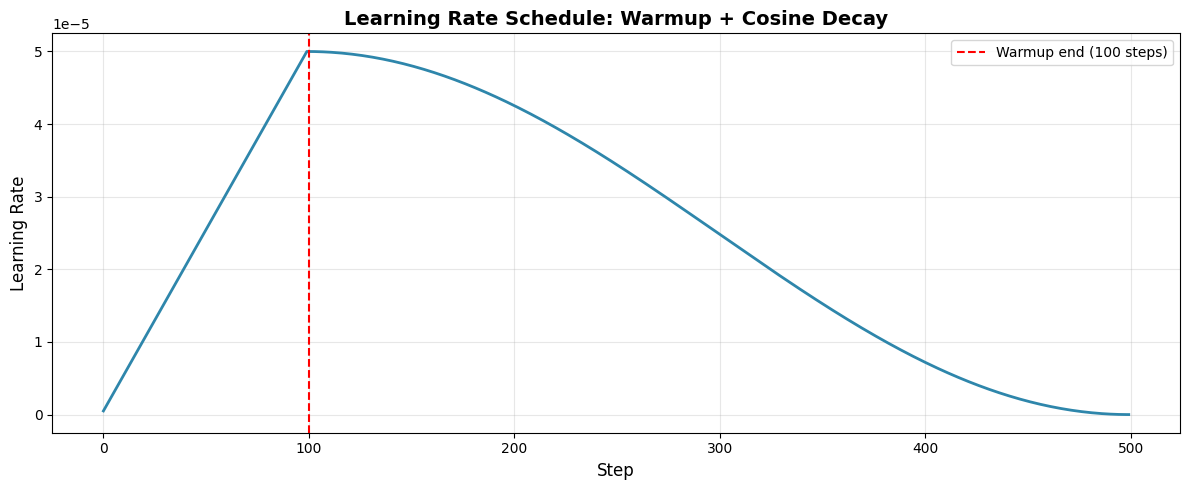

Initial LR: 5.00e-07
LR after warmup (100 steps): 5.00e-05
Final LR (500 steps): 0.00e+00

✓ Learning rate schedule with warmup and cosine decay demonstrated!



In [47]:
class WarmupCosineScheduler:
    """Learning rate scheduler with warmup and cosine decay."""
    def __init__(self, optimizer, warmup_steps, total_steps, initial_lr=5e-5):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.initial_lr = initial_lr
        self.current_step = 0
    
    def step(self):
        """Update learning rate."""
        self.current_step += 1
        
        if self.current_step < self.warmup_steps:
            # Linear warmup
            lr = self.initial_lr * (self.current_step / self.warmup_steps)
        else:
            # Cosine decay
            progress = (self.current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            lr = self.initial_lr * 0.5 * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        return lr


# Demonstrate learning rate scheduling
print("=" * 70)
print("EXERCISE 5.1: LEARNING RATE WARMUP AND COSINE DECAY")
print("=" * 70)

# Create a simple optimizer for demonstration
demo_optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Create scheduler
warmup_steps = 100
total_steps = 500
scheduler = WarmupCosineScheduler(demo_optimizer, warmup_steps, total_steps, 5e-5)

# Visualize learning rate schedule
lrs = []
for step in range(total_steps):
    lr = scheduler.step()
    lrs.append(lr)

# Plot learning rate schedule
plt.figure(figsize=(12, 5))
plt.plot(lrs, linewidth=2, color='#2E86AB')
plt.axvline(warmup_steps, color='red', linestyle='--', label=f'Warmup end ({warmup_steps} steps)')
plt.xlabel('Step', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule: Warmup + Cosine Decay', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial LR: {lrs[0]:.2e}")
print(f"LR after warmup ({warmup_steps} steps): {lrs[warmup_steps]:.2e}")
print(f"Final LR ({total_steps} steps): {lrs[-1]:.2e}")
print("\n✓ Learning rate schedule with warmup and cosine decay demonstrated!\n")

### Exercise 5.2: Analyzing Sampling Strategy Effects

In [48]:
print("=" * 70)
print("EXERCISE 5.2: SAMPLING STRATEGY ANALYSIS")
print("=" * 70)
print("Generating multiple samples to analyze variability:\n")

start_context = "Machine learning"
encoded = text_to_token_ids(start_context, tokenizer).to(device)
max_tokens = 30
num_samples = 3

strategies = {
    "Greedy": {"temperature": 0.0, "top_k": None},
    "Temp 0.7": {"temperature": 0.7, "top_k": None},
    "Temp 1.2": {"temperature": 1.2, "top_k": None},
    "Top-k 10": {"temperature": 1.0, "top_k": 10},
    "Top-k 50": {"temperature": 1.0, "top_k": 50},
}

print(f"Context: '{start_context}'")
print(f"Generating {num_samples} samples per strategy:\n")

model.eval()
for strategy_name, params in strategies.items():
    print(f"\n--- {strategy_name} ---")
    for i in range(num_samples):
        torch.manual_seed(42 + i)  # Different seed for each sample
        output = generate(
            model, encoded.clone(), 
            max_new_tokens=max_tokens,
            context_size=context_size,
            temperature=params["temperature"],
            top_k=params["top_k"]
        )
        text = token_ids_to_text(output, tokenizer)
        # Truncate for display
        display_text = text[:80] + "..." if len(text) > 80 else text
        print(f"  {i+1}. {display_text}")

print("\n" + "=" * 70)
print("ANALYSIS:")
print("-" * 70)
print("• Greedy: Always same output (deterministic)")
print("• Temperature sampling: Varies between runs")
print("• Higher temperature: More variation, potentially less coherent")
print("• Top-k: Ensures quality by excluding low-prob tokens")
print("• Balance: Use temp 0.7-1.0 with top-k 30-50 for best results")
print("=" * 70 + "\n")

EXERCISE 5.2: SAMPLING STRATEGY ANALYSIS
Generating multiple samples to analyze variability:

Context: 'Machine learning'
Generating 3 samples per strategy:


--- Greedy ---
  1. Machine learning the prism of Hermia's tears I felt able to face the fact with e...
  2. Machine learning the prism of Hermia's tears I felt able to face the fact with e...
  3. Machine learning the prism of Hermia's tears I felt able to face the fact with e...

--- Temp 0.7 ---
  1. Machine learning for you?"

"Yes--quite insensible to the irony. She wanted him ...
  2. Machine learning him only course I meant to do the picture for nothing--I told M...
  3. Machine learningases, in the inevitable garlanded frame. The mere outline of the...

--- Temp 1.2 ---
  1. Machine learning for you?"
" thin his pictures? hadstymology hardRegardingorBut ...
  2. Machine learning DAV only billboard dear added immediately virt affiliate challe...
  3. Machine learning vel fewpaper territmini none of glimpse ofig Financebloo

### Exercise 5.3: Impact of Batch Size on Training Dynamics

In [49]:
print("=" * 70)
print("EXERCISE 5.3: BATCH SIZE EFFECTS ON TRAINING")
print("=" * 70)
print("Analyzing how batch size affects training dynamics:\n")

# Test different batch sizes
batch_sizes_to_test = [1, 2, 4]

print(f"{'Batch Size':<12} {'Batches/Epoch':<18} {'Memory Usage':<20}")
print("-" * 70)

for bs in batch_sizes_to_test:
    try:
        temp_loader = create_dataloader_v1(
            train_data, batch_size=bs, max_length=max_length, 
            stride=stride, shuffle=True, drop_last=True
        )
        num_batches = len(temp_loader)
        
        # Estimate memory (rough approximation)
        tokens_per_batch = bs * max_length
        memory_mb = tokens_per_batch * GPT_CONFIG_124M["emb_dim"] * 4 / 1e6
        
        print(f"{bs:<12} {num_batches:<18} ~{memory_mb:.1f} MB per forward pass")
    except Exception as e:
        print(f"{bs:<12} Error: {str(e)[:40]}")

print("\n" + "=" * 70)
print("BATCH SIZE ANALYSIS:")
print("-" * 70)
print("""
Batch Size Effects:

Small batches (1-2):
  + More gradient updates per epoch
  + Better at escaping local minima (noisy gradients)
  + Lower memory requirements
  - Higher variance in gradient estimates
  - May need lower learning rate

Large batches (8+):
  + More stable gradient estimates
  + Can use higher learning rates
  + Better GPU utilization
  - Fewer updates per epoch
  - Higher memory requirements
  - May converge to sharper minima (generalize worse)

Recommendations:
  • Start with batch size 2-4 for experimentation  
  • Scale up batch size with learning rate (linear scaling rule)
  • Use gradient accumulation if memory-limited
  • Monitor validation loss for overfitting
""")
print("=" * 70 + "\n")

EXERCISE 5.3: BATCH SIZE EFFECTS ON TRAINING
Analyzing how batch size affects training dynamics:

Batch Size   Batches/Epoch      Memory Usage        
----------------------------------------------------------------------
1            18                 ~0.8 MB per forward pass
2            9                  ~1.6 MB per forward pass
4            4                  ~3.1 MB per forward pass

BATCH SIZE ANALYSIS:
----------------------------------------------------------------------

Batch Size Effects:

Small batches (1-2):
  + More gradient updates per epoch
  + Better at escaping local minima (noisy gradients)
  + Lower memory requirements
  - Higher variance in gradient estimates
  - May need lower learning rate

Large batches (8+):
  + More stable gradient estimates
  + Can use higher learning rates
  + Better GPU utilization
  - Fewer updates per epoch
  - Higher memory requirements
  - May converge to sharper minima (generalize worse)

Recommendations:
  • Start with batch size 2-

### Exercise 5.4: Gradient Accumulation for Larger Effective Batch Size

In [50]:
print("=" * 70)
print("EXERCISE 5.4: GRADIENT ACCUMULATION")
print("=" * 70)

def train_with_gradient_accumulation(model, train_loader, optimizer, device, 
                                     accumulation_steps=4, num_steps=20):
    """
    Training with gradient accumulation for larger effective batch size.
    
    Effective batch size = actual_batch_size * accumulation_steps
    
    This allows training with large batch sizes even on limited memory.
    """
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    step = 0
    accumulated = 0
    
    for input_batch, target_batch in train_loader:
        if step >= num_steps:
            break
            
        # Forward pass
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        
        # Scale loss by accumulation steps
        loss = loss / accumulation_steps
        loss.backward()
        
        accumulated += 1
        total_loss += loss.item() * accumulation_steps
        
        # Only update weights after accumulating gradients
        if accumulated >= accumulation_steps:
            optimizer.step()
            optimizer.zero_grad()
            accumulated = 0
            step += 1
            
            if step % 5 == 0:
                print(f"  Step {step}: Loss = {total_loss / step:.4f}")
    
    return total_loss / max(step, 1)


print("\nGradient Accumulation Concept:")
print("-" * 70)
print("""
Without gradient accumulation:
  - Batch size = 2, Memory = X
  - 1 gradient update per batch

With gradient accumulation (steps=4):
  - Batch size = 2, Memory = X (same!)
  - Effective batch size = 2 * 4 = 8
  - 1 gradient update per 4 batches
  - Gradients are summed before update
""")

print("\nDemonstrating gradient accumulation...")
print("-" * 70)

# Create fresh model for demo
demo_model = GPTModel(GPT_CONFIG_124M).to(device)
demo_optimizer = torch.optim.AdamW(demo_model.parameters(), lr=1e-4)

# Train with accumulation
avg_loss = train_with_gradient_accumulation(
    demo_model, train_loader, demo_optimizer, device,
    accumulation_steps=4, num_steps=10
)

print(f"\nFinal average loss: {avg_loss:.4f}")
print("\n" + "=" * 70)
print("BENEFITS OF GRADIENT ACCUMULATION:")
print("-" * 70)
print("""
• Train with larger effective batch sizes without more memory
• More stable gradients (averaged over more samples)
• Essential for training large models on consumer GPUs
• Linear scaling: accumulation_steps=4 with batch_size=2 = effective batch_size=8

When to use:
• GPU memory is limited
• You want larger batch sizes for stability
• Training very large models
""")
print("=" * 70 + "\n")

# Cleanup
del demo_model, demo_optimizer

EXERCISE 5.4: GRADIENT ACCUMULATION

Gradient Accumulation Concept:
----------------------------------------------------------------------

Without gradient accumulation:
  - Batch size = 2, Memory = X
  - 1 gradient update per batch

With gradient accumulation (steps=4):
  - Batch size = 2, Memory = X (same!)
  - Effective batch size = 2 * 4 = 8
  - 1 gradient update per 4 batches
  - Gradients are summed before update


Demonstrating gradient accumulation...
----------------------------------------------------------------------

Final average loss: 47.8549

BENEFITS OF GRADIENT ACCUMULATION:
----------------------------------------------------------------------

• Train with larger effective batch sizes without more memory
• More stable gradients (averaged over more samples)
• Essential for training large models on consumer GPUs
• Linear scaling: accumulation_steps=4 with batch_size=2 = effective batch_size=8

When to use:
• GPU memory is limited
• You want larger batch sizes for sta